# 04  Backtest & Strategy Comparison
 
Aggregates the per-fold predictions saved by `scripts/03bis_walk_forward.py` into a continuous out-of-sample track record, computes the paper's full performance table, and benchmarks the DMN variants against simple references.
 
**Variants compared:**
- DMN (LSTM only), paper's baseline
- DMN w/ CPD, paper's main contribution 
- DMN long-only w/ CPD, positions in $(0, 1)$
- **DMN long-only w/ CPD + 25 bps cost-aware loss**
- MACD
- TSMOM (Moskowitz)
- EW-SXXR, equal-weighted portfolio of constituents
- SXXR, cap-weighted reference index
 
 **Metrics used:** annualised return, vol, Sharpe; downside deviation and Sortino; max drawdown and Calmar; hit rate; profit/loss ratio. Reported both raw and rescaled to 15% vol target.

In [1]:
from pathlib import Path
import sys, warnings, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100, "axes.grid": True})

## Configuration

In [2]:
with open(PROJECT_ROOT / "configs" / "default.yaml") as f:
    cfg = yaml.safe_load(f)

PROCESSED_DIR = PROJECT_ROOT / cfg["data"]["processed_dir"]
MODELS_DIR    = PROJECT_ROOT / cfg["data"]["processed_mod"]
TARGET_VOL    = cfg["vol_target"]
CPD_LBW       = cfg["dmn"]["cpd_lbw"]
CPD_STRIDE    = cfg["dmn"].get("cpd_stride", 1)
FOLD_TYPE     = cfg.get("fold_type", "expanding")

# Transaction cost applied at backtest time to all variants
TRANSACTION_COST = 0.0025

print(f"Models dir:        {MODELS_DIR}")
print(f"Target vol:        {TARGET_VOL:.0%}")
print(f"CPD setup:         lbw={CPD_LBW}, stride={CPD_STRIDE}")
print(f"Fold type:         {FOLD_TYPE}")
print(f"Transaction cost:  {TRANSACTION_COST*1e4:.0f} bps")

Models dir:        c:\Users\vonae\Documents\GitHub\Pergam_MSc_2026\data\processed\models
Target vol:        15%
CPD setup:         lbw=21, stride=5
Fold type:         expanding
Transaction cost:  25 bps


## Load DMN predictions
 
Predictions from each fold are concatenated into a single continuous out-of-sample series. We support multiple variants in parallel, the variant suffix (e.g. `cpd21_s5`, `nocpd`, `cpd21_s5_longonly`) is the discriminator. Files matching the pattern but missing on disk are skipped.

In [3]:
def load_variant(suffix: str) -> pd.DataFrame:
    """Concatenate predictions across all folds for a given DMN variant.
    
    Pattern: predictions_fold*_{suffix}.csv
    Returns empty DataFrame if no files match.
    """
    files = sorted(MODELS_DIR.glob(f"predictions_fold*_{suffix}.csv"))
    if not files:
        return pd.DataFrame()
    frames = [pd.read_csv(f, parse_dates=["date"]) for f in files]
    df = pd.concat(frames, ignore_index=True).sort_values(["date", "ticker"])
    df["variant"] = suffix
    return df

# Build the variants registry: maps a readable label to the suffix in the filename.
# Edit this to add/remove variants from the comparison.
VARIANTS = {
    "dmn_baseline":         f"{FOLD_TYPE}_nocpd",
    "dmn_cpd":              f"{FOLD_TYPE}_cpd{CPD_LBW}_s{CPD_STRIDE}",
    "dmn_cpd_longonly":     f"{FOLD_TYPE}_cpd{CPD_LBW}_s{CPD_STRIDE}_longonly",
    "dmn_cpd_longonly_tc":  f"{FOLD_TYPE}_cpd{CPD_LBW}_s{CPD_STRIDE}_longonly_tc25bps",
}

dmn_predictions = {}
for label, suffix in VARIANTS.items():
    df = load_variant(suffix)
    if df.empty:
        print(f"  {label}: no files matching predictions_fold*_{suffix}.csv — skipping")
    else:
        dmn_predictions[label] = df
        print(f"  {label}: {len(df):,} rows, "
              f"{df['date'].min().date()}/{df['date'].max().date()}")

if not dmn_predictions:
    raise FileNotFoundError(
        "No DMN predictions found. Run scripts/03bis_walk_forward.py first."
    )

  dmn_baseline: 491,996 rows, 2011-01-03/2026-04-30
  dmn_cpd: 491,996 rows, 2011-01-03/2026-04-30
  dmn_cpd_longonly: 491,996 rows, 2011-01-03/2026-04-30
  dmn_cpd_longonly_tc: 491,996 rows, 2011-01-03/2026-04-30


## Load benchmarks and the processed panel
 
We need the panel to compute the classical TSMOM and MACD reference signals on the same dates as the DMN test predictions, ensuring a fair comparison.

In [4]:
benchmarks = pd.read_csv(PROCESSED_DIR / "benchmark_stoxx600_ew.csv",
                         parse_dates=["date"])
print(f"Benchmarks: {len(benchmarks):,} rows, "
      f"{benchmarks['benchmark'].unique().tolist()}")

stocks = pd.read_csv(
    PROCESSED_DIR / "stoxx600_processed.csv",
    parse_dates=["date"],
    usecols=["date", "ticker", "1d_arith_ret", "60d_ewm_vol",
             "252d_arith_ret", "macd_8_24", "macd_16_48", "macd_32_96"],
)

oos_start = min(df["date"].min() for df in dmn_predictions.values())
oos_end   = max(df["date"].max() for df in dmn_predictions.values())
stocks_oos = stocks.loc[(stocks["date"] >= oos_start) &
                         (stocks["date"] <= oos_end)].copy()
print(f"Out-of-sample period: {oos_start.date()}/{oos_end.date()} "
      f"({stocks_oos['date'].nunique():,} days, {stocks_oos['ticker'].nunique():,} tickers)")

Benchmarks: 10,528 rows, ['SXXR', 'EW']
Out-of-sample period: 2011-01-03/2026-04-30 (3,999 days, 1,150 tickers)


## Build paper's reference strategies
 
These are computed on the same panel and dates as the DMN predictions to ensure a fair side-by-side comparison.

- **Long-only**: $X_t = 1$ for every stock (= EW-SXXR portfolio).
- **Moskowitz** ($w=0$): $X_t = \mathrm{sgn}(r_{t-252,t})$.
- **MACD**: sign of the average of three vol-normalised MACD signals.

In [6]:
def vol_scaled_strategy_return(positions, ret_real, ex_ante_vol, target_vol=TARGET_VOL):
    """Apply paper Eq. 11 vol scaling to per-(stock, date) positions."""
    return positions * (target_vol / np.maximum(ex_ante_vol, 1e-6)) * ret_real

stocks_oos["pos_long_only"] = 1.0
stocks_oos["pos_moskowitz"] = np.sign(stocks_oos["252d_arith_ret"].fillna(0.0))

macd_signal = stocks_oos[["macd_8_24", "macd_16_48", "macd_32_96"]].mean(axis=1)
stocks_oos["pos_macd"] = np.sign(macd_signal.fillna(0.0))

for name in ["long_only", "moskowitz", "macd"]:
    stocks_oos[f"strat_{name}_gross"] = vol_scaled_strategy_return(
        stocks_oos[f"pos_{name}"],
        stocks_oos["1d_arith_ret"].shift(-1),  # held over next day
        stocks_oos["60d_ewm_vol"],
    )

classical_cols = ["date", "ticker", "60d_ewm_vol"] + \
                 [f"pos_{n}" for n in ["long_only", "moskowitz", "macd"]] + \
                 [f"strat_{n}_gross" for n in ["long_only", "moskowitz", "macd"]]
classical = (stocks_oos[classical_cols]
              .dropna(subset=[f"strat_{n}_gross" for n in ["long_only", "moskowitz", "macd"]])
              .reset_index(drop=True))
print(f"Classical strategies computed on {len(classical):,} (stock, date) pairs")

Classical strategies computed on 2,211,550 (stock, date) pairs


## Apply transaction costs (paper Eq. C1)
 
The cost is proportional to the change in the vol-scaled position $X_t / \sigma_t$ between consecutive periods. We apply this at the backtest layer to all variants uniformly, even those already trained with cost-aware loss, so the comparison is fair (every strategy bears the same realised transaction cost).

For the DMN variants, the file already contains `strat_ret_gross` and `strat_ret` columns (net of training-time costs if applicable). Here we recompute net returns at the backtest cost level, overwriting `strat_ret`.

In [ ]:
def add_transaction_costs(df: pd.DataFrame, position_col: str, vol_col: str,
                          gross_col: str, net_col: str,
                          cost: float = TRANSACTION_COST,
                          target_vol: float = TARGET_VOL) -> pd.DataFrame:
    """Subtract cost * target_vol * |Δ(X / sigma)| from the gross strategy return.
    
    Per-ticker turnover; output written to `net_col`.
    """
    df = df.sort_values(["ticker", "date"]).copy()
    df["_scaled_pos"]   = df[position_col] / np.maximum(df[vol_col], 1e-6)
    df["_d_scaled_pos"] = df.groupby("ticker")["_scaled_pos"].diff().fillna(0.0)
    df[net_col] = df[gross_col] - cost * target_vol * df["_d_scaled_pos"].abs()
    return df.drop(columns=["_scaled_pos", "_d_scaled_pos"])
# the cost is charged every day on which the position in a stock changed, proportional to how much it changed.

# DMN variants: recompute net returns at backtest cost level
# (overwrites the strat_ret column from the predictions file)
for label, df in dmn_predictions.items():
    if "strat_ret_gross" not in df.columns:
        # Backward compat: old prediction files only have strat_ret
        df["strat_ret_gross"] = df["strat_ret"].copy()
    dmn_predictions[label] = add_transaction_costs(
        df, position_col="position", vol_col="ex_ante_vol",
        gross_col="strat_ret_gross", net_col="strat_ret"
    )

# Classical strategies
for name in ["long_only", "moskowitz", "macd"]:
    classical = add_transaction_costs(
        classical, position_col=f"pos_{name}", vol_col="60d_ewm_vol",
        gross_col=f"strat_{name}_gross", net_col=f"strat_{name}"
    )

## Aggregate to portfolio level
 
Equal-weighted across stocks at each date. This matches the paper's convention (the strategy is defined per asset, then averaged).

In [8]:
def to_portfolio_series(df: pd.DataFrame, strat_col: str) -> pd.Series:
    return df.groupby("date")[strat_col].mean().sort_index()

portfolios = {}

# DMN variants: gross + net
for label, df in dmn_predictions.items():
    portfolios[f"{label}_gross"] = to_portfolio_series(df, "strat_ret_gross")
    portfolios[f"{label}_net"]   = to_portfolio_series(df, "strat_ret")

# Classical strategies: gross + net
for name in ["long_only", "moskowitz", "macd"]:
    portfolios[f"{name}_gross"] = to_portfolio_series(classical, f"strat_{name}_gross")
    portfolios[f"{name}_net"]   = to_portfolio_series(classical, f"strat_{name}")

# SXXR (cap-weighted reference) — no cost adjustment, it's an index level
sxxr_prices  = (benchmarks.loc[benchmarks["benchmark"] == "SXXR"]
                           .set_index("date")["price"].sort_index())
portfolios["sxxr"] = (sxxr_prices.pct_change()
                                  .loc[(sxxr_prices.index >= oos_start) &
                                       (sxxr_prices.index <= oos_end)])

print(f"Portfolios computed: {len(portfolios)} series")

Portfolios computed: 15 series


## Performance metrics
 
Replicates paper Exhibit 3. All metrics annualised, returns compound daily, drawdowns continuous from peak.

In [ ]:
def compute_metrics(returns: pd.Series) -> dict:
    """Standard performance metrics for a daily strategy return series."""
    r = returns.dropna()
    if len(r) < 2:
        return {k: np.nan for k in [
            "Returns", "Vol", "Sharpe", "Downside Dev", "Sortino",
            "MDD", "Calmar", "% +ve", "Avg P / Avg L"
        ]}
    
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    
    downside = r[r < 0]
    dd_dev   = downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan
    sortino  = ann_ret / dd_dev if dd_dev > 0 else np.nan
    
    cum = (1 + r).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    mdd = dd.min()
    calmar = ann_ret / abs(mdd) if mdd != 0 else np.nan
    
    pct_pos = (r > 0).mean()
    avg_p   = r[r > 0].mean()
    avg_l   = abs(r[r < 0].mean())
    p_to_l  = avg_p / avg_l if avg_l > 0 else np.nan
    
    return {
        "Returns": ann_ret, "Vol": ann_vol, "Sharpe": sharpe,
        "Downside Dev": dd_dev, "Sortino": sortino,
        "MDD": mdd, "Calmar": calmar,
        "% +ve": pct_pos, "Avg P / Avg L": p_to_l,
    }


def format_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Pretty-print formatting for the metrics table."""
    fmt = df.copy()
    for col in ["Returns", "Vol", "Downside Dev", "MDD"]:
        fmt[col] = fmt[col].map(lambda x: f"{x:+.2%}" if pd.notna(x) else "—")
    for col in ["Sharpe", "Sortino", "Calmar", "Avg P / Avg L"]:
        fmt[col] = fmt[col].map(lambda x: f"{x:+.3f}" if pd.notna(x) else "—")
    fmt["% +ve"] = fmt["% +ve"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "—")
    return fmt


# Master metrics table
metric_rows = []
for label, ret_series in portfolios.items():
    m = compute_metrics(ret_series)
    m["Strategy"] = label
    metric_rows.append(m)

metrics_df = (pd.DataFrame(metric_rows).set_index("Strategy")
              [["Returns", "Vol", "Sharpe", "Downside Dev",
                "Sortino", "MDD", "Calmar", "% +ve", "Avg P / Avg L"]])

print(f"\nFull-period out-of-sample metrics:")
print(f"({TRANSACTION_COST*1e4:.0f} bps backtest-time costs applied to all variants)\n")
print(format_metrics(metrics_df).to_string())


Full-period out-of-sample metrics:
(25 bps backtest-time costs applied to all variants)

                          Returns      Vol  Sharpe Downside Dev Sortino      MDD  Calmar  % +ve Avg P / Avg L
Strategy                                                                                                     
dmn_baseline_gross         +0.51%   +1.05%  +0.488       +0.88%  +0.583   -3.58%  +0.143  51.7%        +1.035
dmn_baseline_net           -1.12%   +1.05%  -1.068       +0.84%  -1.340  -14.10%  -0.080  42.8%        +1.076
dmn_cpd_gross              +0.22%   +0.79%  +0.280       +0.75%  +0.299   -3.24%  +0.069  51.9%        +0.987
dmn_cpd_net                -1.18%   +0.80%  -1.486       +0.71%  -1.676  -14.48%  -0.082  42.1%        +0.984
dmn_cpd_longonly_gross     +1.13%   +3.30%  +0.343       +2.90%  +0.391   -8.69%  +0.130  53.8%        +0.921
dmn_cpd_longonly_net       +0.45%   +3.30%  +0.135       +2.87%  +0.155   -8.87%  +0.050  52.1%        +0.946
dmn_cpd_longonly_tc_gross  +1.

We trained only one model specifically to be cost-aware (suffix `_tc`), but the backtest then charges costs to everyone equally.


| | **gross (no cost charged)** | **net (25 bps charged)** |
| :--- | :--- | :--- |
| **trained without cost term** | `dmn_cpd_longonly_gross` | ``dmn_cpd_longonly_net`` |
| **trained with cost term** | `dmn_cpd_longonly_tc_gross` | ``dmn_cpd_longonly_tc_net`` |

Maybe from the results we can say that at 25 bps, cost-aware training has a marginal, possibly-noise effect on this dataset

## Vol-rescaled metrics (paper Exhibit 4)
 
Each strategy rescaled to 15% annualised vol so risk-adjusted comparison is direct (all strategies have the same vol).

In [11]:
def rescale_to_target_vol(returns: pd.Series, target_vol=TARGET_VOL) -> pd.Series:
    r = returns.dropna()
    if len(r) < 2: return r
    realised_vol = r.std() * np.sqrt(252)
    if realised_vol == 0: return r
    return r * (target_vol / realised_vol)

rescaled = {label: rescale_to_target_vol(s) for label, s in portfolios.items()}

rescaled_metric_rows = []
for label, ret_series in rescaled.items():
    m = compute_metrics(ret_series)
    m["Strategy"] = label
    rescaled_metric_rows.append(m)

rescaled_metrics_df = (pd.DataFrame(rescaled_metric_rows).set_index("Strategy")
                       [["Returns", "Vol", "Sharpe", "Downside Dev",
                         "Sortino", "MDD", "Calmar", "% +ve", "Avg P / Avg L"]])

print(f"\nVol-rescaled metrics (paper Exhibit 4 format, all at {TARGET_VOL:.0%} vol):\n")
print(format_metrics(rescaled_metrics_df).to_string())


Vol-rescaled metrics (paper Exhibit 4 format, all at 15% vol):

                           Returns      Vol  Sharpe Downside Dev Sortino      MDD  Calmar  % +ve Avg P / Avg L
Strategy                                                                                                      
dmn_baseline_gross          +7.33%  +15.00%  +0.488      +12.56%  +0.583  -42.65%  +0.172  51.7%        +1.035
dmn_baseline_net           -16.02%  +15.00%  -1.068      +11.96%  -1.340  -89.83%  -0.178  42.8%        +1.076
dmn_cpd_gross               +4.21%  +15.00%  +0.280      +14.07%  +0.299  -49.01%  +0.086  51.9%        +0.987
dmn_cpd_net                -22.28%  +15.00%  -1.486      +13.29%  -1.676  -95.42%  -0.234  42.1%        +0.984
dmn_cpd_longonly_gross      +5.15%  +15.00%  +0.343      +13.17%  +0.391  -35.13%  +0.147  53.8%        +0.921
dmn_cpd_longonly_net        +2.03%  +15.00%  +0.135      +13.04%  +0.155  -35.86%  +0.057  52.1%        +0.946
dmn_cpd_longonly_tc_gross   +4.47%  +15.00%  +0

## Equity curves
 
Top: raw signal output. Bottom: vol-rescaled to 15% (directly comparable on a risk-adjusted basis).

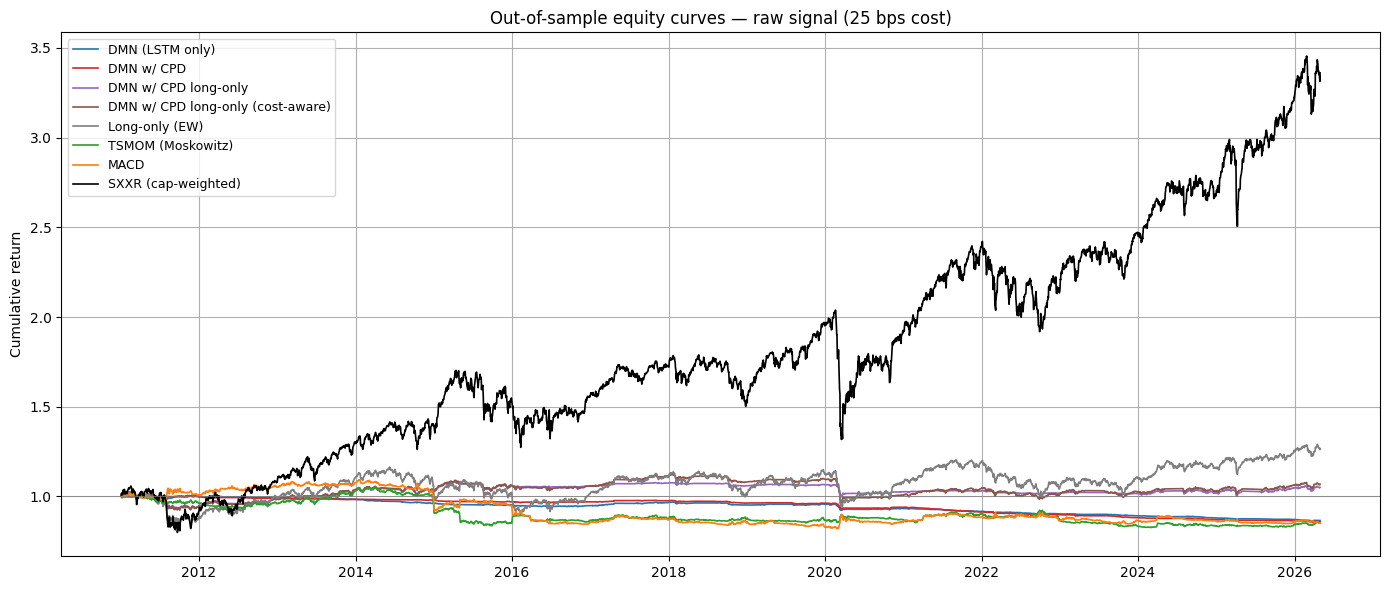

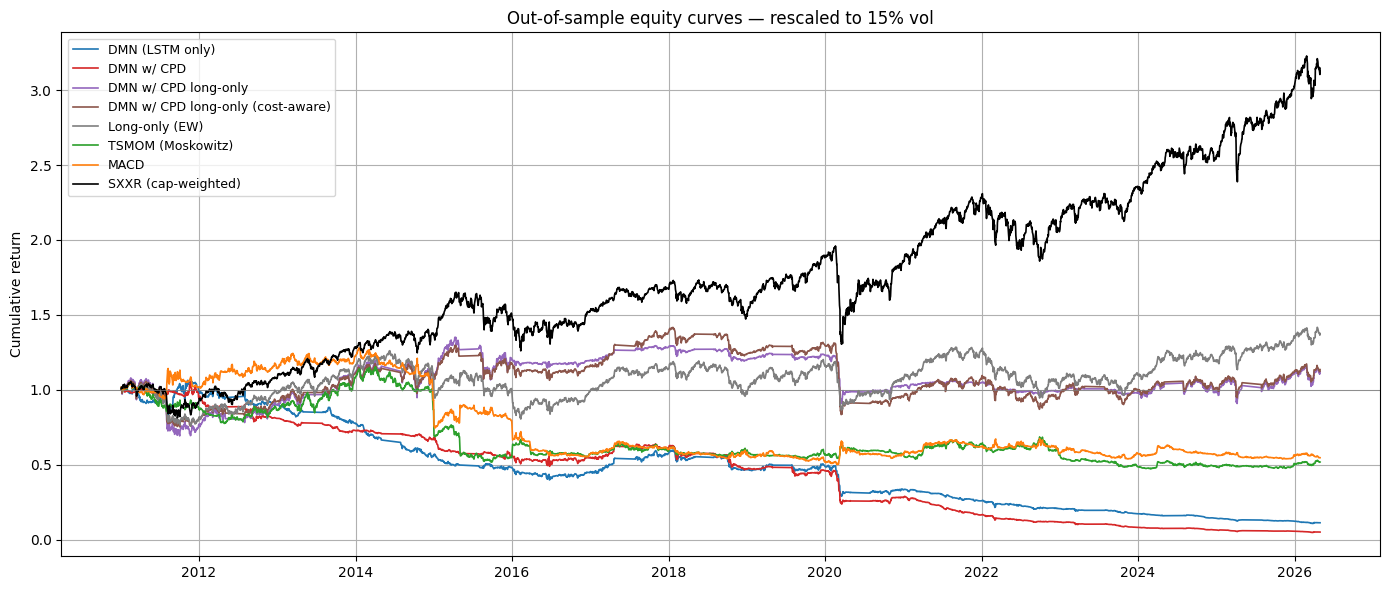

In [12]:
PALETTE = {
    "dmn_baseline_net":           "#1f77b4",
    "dmn_cpd_net":                "#d62728",
    "dmn_cpd_longonly_net":       "#9467bd",
    "dmn_cpd_longonly_tc_net":    "#8c564b",
    "long_only_net":              "#7f7f7f",
    "moskowitz_net":              "#2ca02c",
    "macd_net":                   "#ff7f0e",
    "sxxr":                       "#000000",
}
LABELS = {
    "dmn_baseline_net":           "DMN (LSTM only)",
    "dmn_cpd_net":                "DMN w/ CPD",
    "dmn_cpd_longonly_net":       "DMN w/ CPD long-only",
    "dmn_cpd_longonly_tc_net":    "DMN w/ CPD long-only (cost-aware)",
    "long_only_net":              "Long-only (EW)",
    "moskowitz_net":              "TSMOM (Moskowitz)",
    "macd_net":                   "MACD",
    "sxxr":                       "SXXR (cap-weighted)",
}

def plot_equity_curves(portfolios_dict, title_suffix, palette, labels, log=False):
    fig, ax = plt.subplots(figsize=(14, 6))
    for label, ret in portfolios_dict.items():
        if label not in palette:
            continue
        cum = (1 + ret.dropna()).cumprod()
        ax.plot(cum.index, cum.values, lw=1.2,
                color=palette[label], label=labels[label])
    if log:
        ax.set_yscale("log")
    ax.set_title(f"Out-of-sample equity curves — {title_suffix}")
    ax.set_ylabel("Cumulative return" + (" (log)" if log else ""))
    ax.axhline(1.0, color="gray", lw=0.5)
    ax.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

plot_equity_curves(portfolios, f"raw signal ({TRANSACTION_COST*1e4:.0f} bps cost)", PALETTE, LABELS, log=False)
plot_equity_curves(rescaled, f"rescaled to {TARGET_VOL:.0%} vol", PALETTE, LABELS, log=False)

## Drawdown Analysis

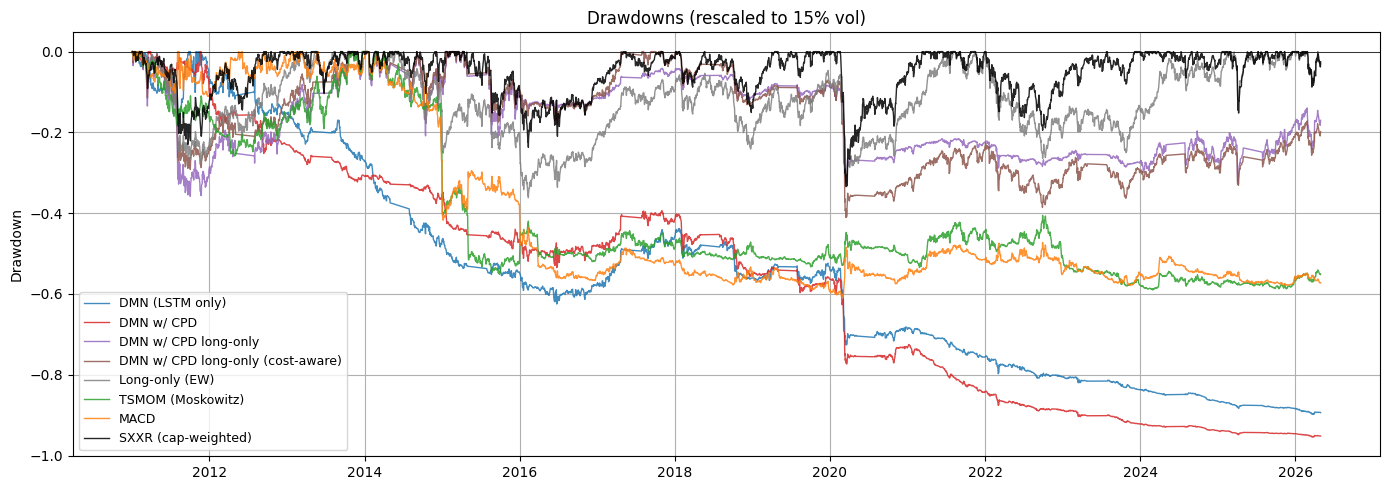

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
for label, ret in rescaled.items():
    if label not in PALETTE:
        continue
    cum = (1 + ret.dropna()).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    ax.plot(dd.index, dd.values, lw=1.0, color=PALETTE[label],
             label=LABELS[label], alpha=0.85)
ax.set_title(f"Drawdowns (rescaled to {TARGET_VOL:.0%} vol)")
ax.set_ylabel("Drawdown")
ax.axhline(0, color="black", lw=0.5)
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

## Rolling Sharpe ratio
 
Trailing 252-day Sharpe assesses regime-dependence and the CPD module's value-add over time.


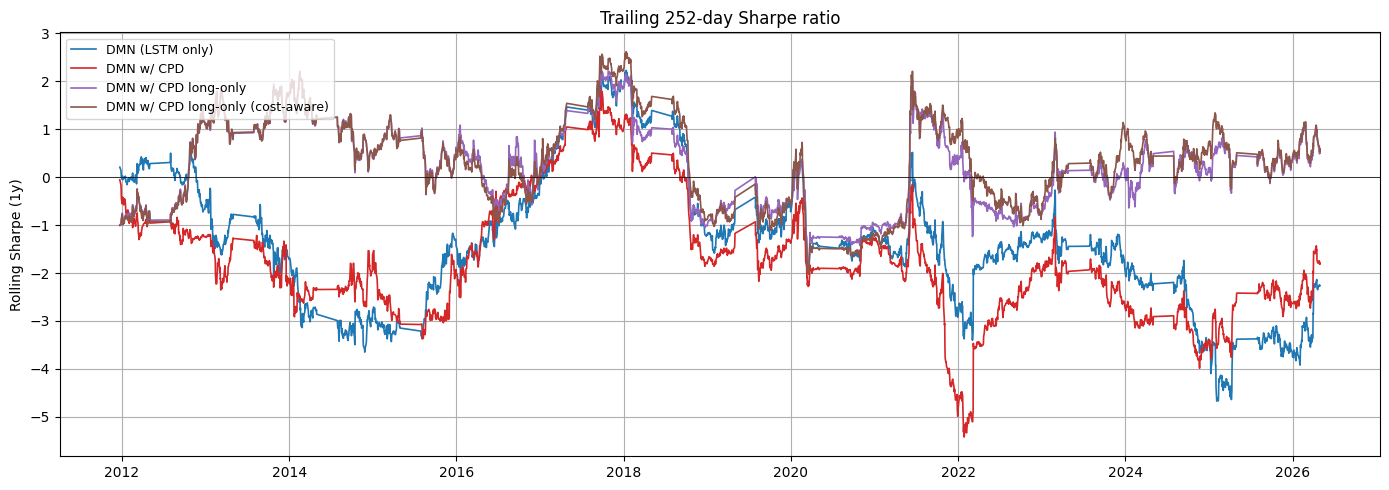

In [14]:
def rolling_sharpe(returns: pd.Series, window: int = 252) -> pd.Series:
    r = returns.dropna()
    return (r.rolling(window).mean() / r.rolling(window).std()) * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
for label in ["dmn_baseline_net", "dmn_cpd_net",
               "dmn_cpd_longonly_net", "dmn_cpd_longonly_tc_net"]:
    if label not in portfolios:
        continue
    rs = rolling_sharpe(portfolios[label])
    ax.plot(rs.index, rs.values, lw=1.2, color=PALETTE[label],
             label=LABELS[label])

ax.axhline(0, color="black", lw=0.5)
ax.set_title("Trailing 252-day Sharpe ratio")
ax.set_ylabel("Rolling Sharpe (1y)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Sharpe by year
 
Cross-year breakdown for regime-dependence analysis. The paper notes the CPD module is especially valuable in 2015-2020.

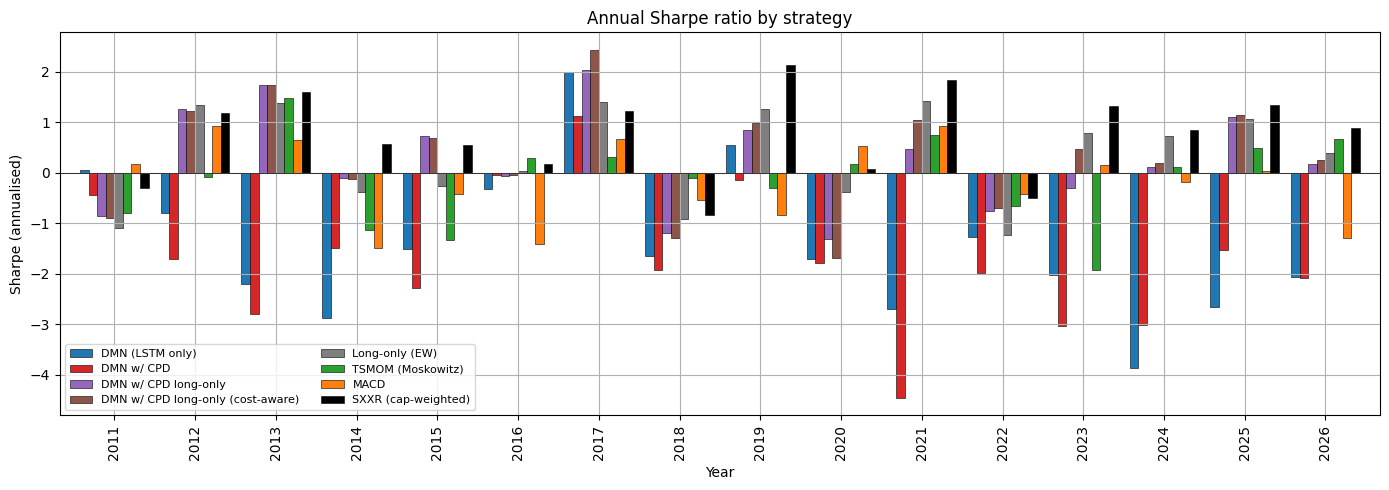


Sharpe by year:
      DMN (LSTM only)  DMN w/ CPD  DMN w/ CPD long-only  DMN w/ CPD long-only (cost-aware)  Long-only (EW)  TSMOM (Moskowitz)  MACD  SXXR (cap-weighted)
date                                                                                                                                                    
2011             0.05       -0.43                 -0.86                              -0.89           -1.09              -0.80  0.18                -0.29
2012            -0.80       -1.71                  1.27                               1.23            1.34              -0.09  0.92                 1.18
2013            -2.21       -2.79                  1.75                               1.75            1.38               1.48  0.65                 1.60
2014            -2.87       -1.50                 -0.10                              -0.12           -0.38              -1.12 -1.48                 0.58
2015            -1.51       -2.29                  0.73          

In [15]:
def yearly_sharpe(returns: pd.Series) -> pd.Series:
    r = returns.dropna()
    return r.groupby(r.index.year).apply(
        lambda y: (y.mean() / y.std()) * np.sqrt(252) if y.std() > 0 else 0.0
    )

yearly_table = pd.DataFrame({
    LABELS[label]: yearly_sharpe(portfolios[label])
    for label in PALETTE if label in portfolios
})

fig, ax = plt.subplots(figsize=(14, 5))
yearly_table.plot(
    kind="bar", ax=ax,
    color=[PALETTE[l] for l in PALETTE if LABELS[l] in yearly_table.columns],
    width=0.85, edgecolor="black", linewidth=0.4,
)
ax.set_title("Annual Sharpe ratio by strategy")
ax.set_ylabel("Sharpe (annualised)")
ax.set_xlabel("Year")
ax.axhline(0, color="black", lw=0.5)
ax.legend(fontsize=8, ncol=2, loc="lower left")
plt.tight_layout()
plt.show()

print(f"\nSharpe by year:")
print(yearly_table.round(2).to_string())

## Transaction cost sensitivity (paper Exhibit 8)
 
How does Sharpe degrade as we increase per-transaction cost from 0 bps to 50 bps? The paper notes DMNs deteriorate quickly above ~2 bps without a cost-aware loss; with a cost-aware model (our `dmn_cpd_longonly_tc` variant), we expect more graceful degradation.

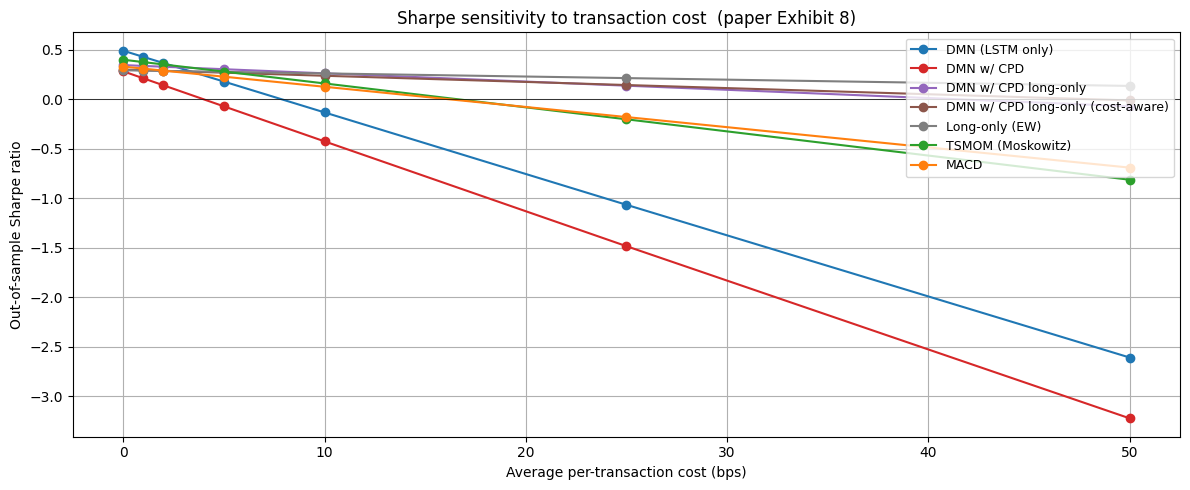


Sharpe at each cost level:
            dmn_baseline  dmn_cpd  dmn_cpd_longonly  dmn_cpd_longonly_tc  long_only  moskowitz   macd
Cost (bps)                                                                                           
0                  0.488    0.280             0.343                0.298      0.291      0.397  0.328
1                  0.426    0.210             0.335                0.291      0.288      0.374  0.308
2                  0.364    0.139             0.327                0.285      0.285      0.350  0.287
5                  0.177   -0.073             0.302                0.267      0.275      0.278  0.226
10                -0.135   -0.427             0.260                0.235      0.259      0.158  0.124
25                -1.068   -1.486             0.135                0.142      0.212     -0.204 -0.182
50                -2.610   -3.224            -0.073               -0.013      0.133     -0.815 -0.692


In [ ]:
COST_GRID_BPS = [0, 1, 2, 5, 10, 25, 50]
COST_GRID = [c * 1e-4 for c in COST_GRID_BPS]


def sharpe_at_cost(df: pd.DataFrame, cost: float, position_col="position",
                    vol_col="ex_ante_vol", gross_col="strat_ret_gross") -> float:
    """Re-derive Sharpe after subtracting per-ticker turnover cost."""
    adj = add_transaction_costs(
        df, position_col=position_col, vol_col=vol_col,
        gross_col=gross_col, net_col="_tmp_net", cost=cost
    )
    port = to_portfolio_series(adj, "_tmp_net")
    return compute_metrics(port).get("Sharpe", np.nan)


cost_sens = {}
for label, df in dmn_predictions.items():
    cost_sens[label] = [sharpe_at_cost(df, c) for c in COST_GRID]

for name in ["long_only", "moskowitz", "macd"]:
    sharpes = []
    for c in COST_GRID:
        sharpes.append(sharpe_at_cost(
            classical, c,
            position_col=f"pos_{name}", vol_col="60d_ewm_vol",
            gross_col=f"strat_{name}_gross"
        ))
    cost_sens[name] = sharpes

cost_table = pd.DataFrame(cost_sens, index=COST_GRID_BPS)
cost_table.index.name = "Cost (bps)"

fig, ax = plt.subplots(figsize=(12, 5))
for label in cost_table.columns:
    color = PALETTE.get(label + "_net", PALETTE.get(label, None))
    ax.plot(cost_table.index, cost_table[label], marker="o", lw=1.5,
             label=LABELS.get(label + "_net", LABELS.get(label, label)),
             color=color)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Average per-transaction cost (bps)")
ax.set_ylabel("Out-of-sample Sharpe ratio")
ax.set_title("Sharpe sensitivity to transaction cost  (paper Exhibit 8)")
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout()
plt.show()

print(f"\nSharpe at each cost level:")
print(cost_table.round(3).to_string())